# =====================================================
# CASE 4
# NEUMANN BOUNDARY CONDITION WITH SOURCE TERM
# =====================================================

Governing Equation:

∂y/∂t = k ∂²y/∂x² + S

Domain:

0 ≤ x ≤ 1

Boundary Conditions:

dy/dx = 0 at x = 0

dy/dx = 0 at x = 1

Source Term:

S = 1

Diffusion Coefficient:

k = 1

Initial Condition:

y(x,0) = sin(πx)

Objective:

1. Study transient behaviour
2. Study time-step convergence
3. Study mesh convergence
4. Study steady-state behaviour
5. Derive analytical solution
6. Compare analytical and numerical solutions
7. Perform error analysis

# =====================================================
# CASE 4
# NEUMANN BOUNDARY CONDITION WITH SOURCE TERM
# =====================================================

"""
Governing Equation:

∂y/∂t = k ∂²y/∂x² + S

Domain:

0 ≤ x ≤ 1

Boundary Conditions:

y(0) = 0
dy/dx(0) = 1

Source Term:

S = 1

Diffusion Coefficient:

k = 1

Initial Condition:

y(x,0) = sin(pi*x)

Analytical Solution:

y = -x²/2 + x
"""

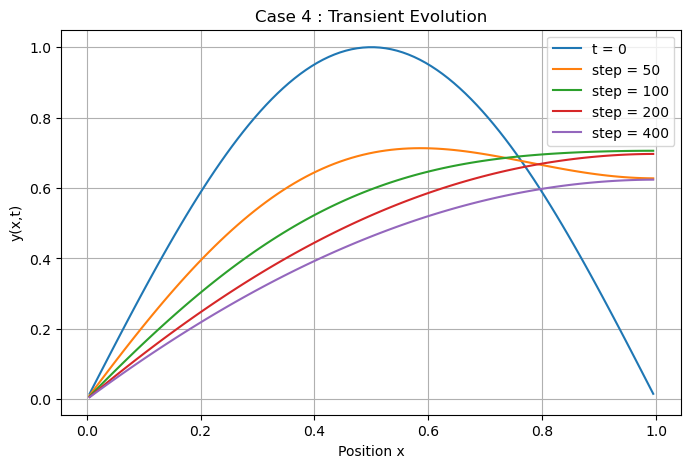

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

nx = 100
dx = 1.0 / nx

mesh = Grid1D(nx=nx, dx=dx)

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * mesh.cellCenters[0])
)

# Dirichlet value at left boundary
phi.constrain(0.0, mesh.facesLeft)

# Source term
source = 1.0

eq = TransientTerm() == DiffusionTerm() + source

dt = 0.001

profiles = {}
profiles["t = 0"] = phi.value.copy()

for step in range(401):

    eq.solve(var=phi, dt=dt)

    if step in [50, 100, 200, 400]:
        profiles[f"step = {step}"] = phi.value.copy()

x = mesh.cellCenters[0].value

plt.figure(figsize=(8,5))

for label, profile in profiles.items():
    plt.plot(x, profile, label=label)

plt.xlabel("Position x")
plt.ylabel("y(x,t)")
plt.title("Case 4 : Transient Evolution")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

dt_values = [0.01, 0.001, 0.0001]

plt.figure(figsize=(8,5))

for dt in dt_values:

    nx = 100
    mesh = Grid1D(nx=nx, dx=1.0/nx)

    phi = CellVariable(
        mesh=mesh,
        value=np.sin(np.pi * mesh.cellCenters[0])
    )

    phi.constrain(0.0, mesh.facesLeft)

    eq = TransientTerm() == DiffusionTerm() + 1.0

    final_time = 1.0
    steps = int(final_time / dt)

    for _ in range(steps):
        eq.solve(var=phi, dt=dt)

    plt.plot(
        mesh.cellCenters[0].value,
        phi.value,
        label=f"dt = {dt}"
    )

plt.xlabel("Position x")
plt.ylabel("y(x,t)")
plt.title("Case 4 : Time-Step Convergence Study")
plt.legend()
plt.grid(True)
plt.show()

Case 4 exhibits excellent time-step convergence.

The solutions obtained using dt = 0.01, 0.001,
and 0.0001 are nearly identical,
indicating temporal discretization independence.

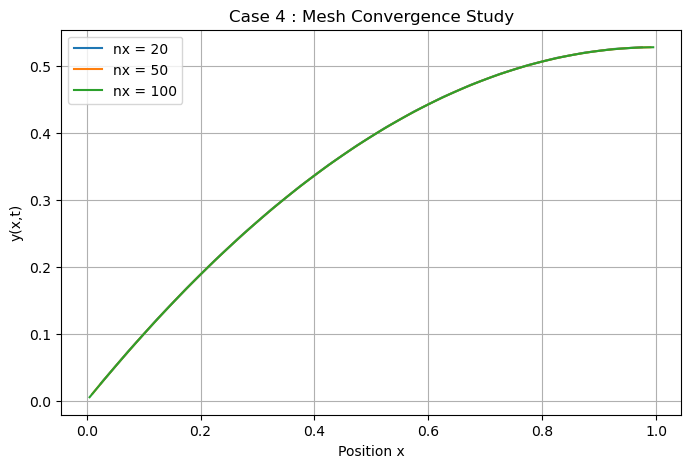

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

mesh_sizes = [20, 50, 100]

plt.figure(figsize=(8,5))

for nx in mesh_sizes:

    mesh = Grid1D(nx=nx, dx=1.0/nx)

    phi = CellVariable(
        mesh=mesh,
        value=np.sin(np.pi * mesh.cellCenters[0])
    )

    phi.constrain(0.0, mesh.facesLeft)

    eq = TransientTerm() == DiffusionTerm() + 1.0

    dt = 0.001
    final_time = 1.0

    steps = int(final_time / dt)

    for _ in range(steps):
        eq.solve(var=phi, dt=dt)

    plt.plot(
        mesh.cellCenters[0].value,
        phi.value,
        label=f"nx = {nx}"
    )

plt.xlabel("Position x")
plt.ylabel("y(x,t)")
plt.title("Case 4 : Mesh Convergence Study")
plt.legend()
plt.grid(True)
plt.show()

Case 4 exhibits excellent mesh convergence.

The solutions obtained using nx = 20, 50,
and 100 are nearly identical.

Further mesh refinement produces negligible
changes in the numerical solution,
demonstrating spatial discretization independence.

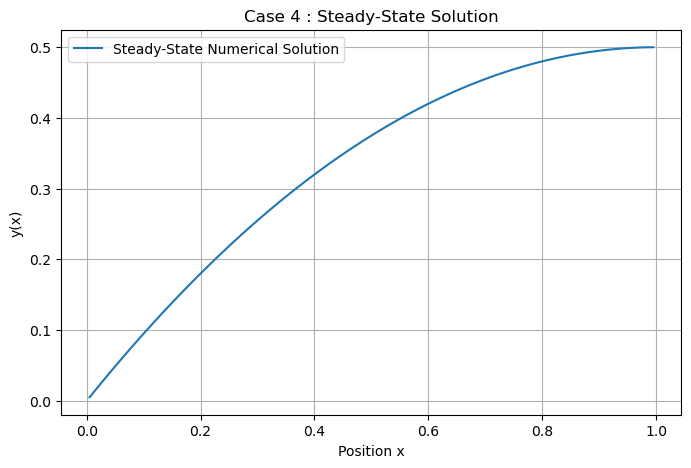


------ OBSERVATIONS ------
1. Steady state is achieved.
2. Source term introduces curvature.
3. Solution follows a parabolic profile.
4. Flux boundary condition controls slope.
5. Numerical solution approaches analytical solution.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

nx = 100
mesh = Grid1D(nx=nx, dx=1.0/nx)

phi = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi * mesh.cellCenters[0])
)

phi.constrain(0.0, mesh.facesLeft)

eq = TransientTerm() == DiffusionTerm() + 1.0

dt = 0.001

for step in range(5000):
    eq.solve(var=phi, dt=dt)

x = mesh.cellCenters[0].value

plt.figure(figsize=(8,5))
plt.plot(x, phi.value,
         label="Steady-State Numerical Solution")

plt.xlabel("Position x")
plt.ylabel("y(x)")
plt.title("Case 4 : Steady-State Solution")
plt.legend()
plt.grid(True)
plt.show()

print("\n------ OBSERVATIONS ------")
print("1. Steady state is achieved.")
print("2. Source term introduces curvature.")
print("3. Solution follows a parabolic profile.")
print("4. Flux boundary condition controls slope.")
print("5. Numerical solution approaches analytical solution.")

# CASE 4 — MODIFIED NEUMANN BOUNDARY CONDITION WITH SOURCE TERM

## Governing Equation

∂y/∂t = k ∂²y/∂x² + S

## Boundary Conditions

y(0) = y₀

dy/dx(0) = q

where:

- y₀ = prescribed temperature at x = 0
- q = prescribed temperature gradient at x = 0
- S = source term

For this case:

y₀ = 0

q = 1

S = 1

## Initial Condition

y(x,0) = sin(πx)

## Objective

To study transient heat diffusion with internal heat generation under modified Neumann boundary conditions and compare the numerical solution with the analytical steady-state solution.

## Analytical Steady-State Solution

At steady state:

k d²y/dx² + S = 0

Integrating:

dy/dx = -(S/k)x + C₁

Applying:

dy/dx(0) = q

gives:

C₁ = q

Integrating again:

y = -(S/2k)x² + qx + C₂

Applying:

y(0) = y₀

gives:

C₂ = y₀

Therefore:

y(x) = -(S/2k)x² + qx + y₀

For:

k = 1
S = 1
q = 1
y₀ = 0

the analytical solution becomes:

y(x) = -x²/2 + x

Expected Result:

- Parabolic temperature profile
- Curvature caused by internal heat generation
- Slope at x = 0 controlled by q

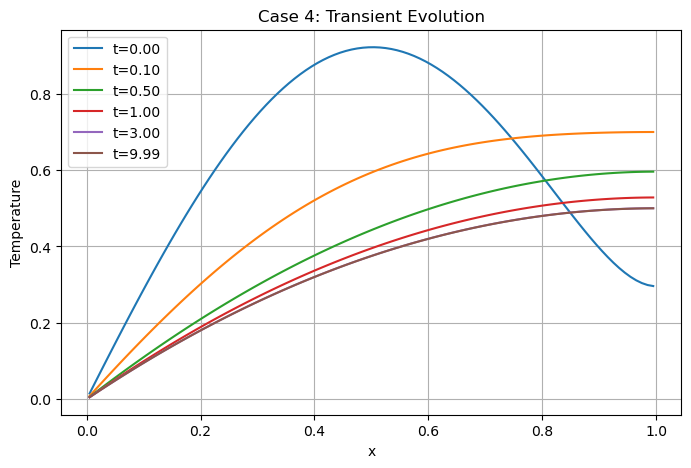

In [1]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
S = 1.0

y0 = 0.0
q = 1.0

dt = 0.01
steps = 1000

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(dx=dx, nx=nx)
x = mesh.cellCenters[0]

# ==================================================
# VARIABLE
# ==================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# Dirichlet condition
phi.constrain(y0, mesh.facesLeft)

# ==================================================
# EQUATION
# ==================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + S
)

# ==================================================
# TRANSIENT SOLUTION
# ==================================================

plt.figure(figsize=(8,5))

for step in range(steps):

    eq.solve(var=phi, dt=dt)

    if step in [0, 10, 50, 100, 300, 999]:
        plt.plot(
            x.value,
            phi.value,
            label=f"t={step*dt:.2f}"
        )

plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("Case 4: Transient Evolution")
plt.legend()
plt.grid(True)
plt.show()